In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [14]:
X, y = make_circles(n_samples=1000, noise=0.1, random_state=1)

<Axes: >

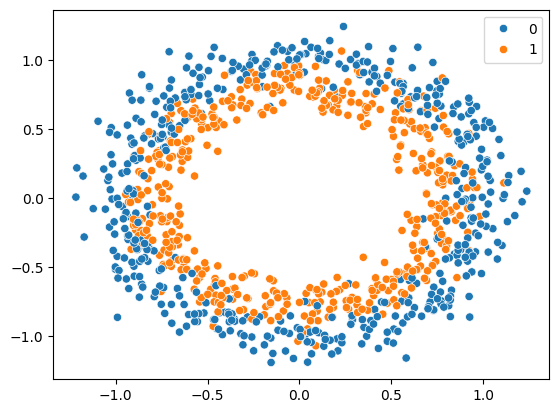

In [15]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

In [17]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [19]:
callback = EarlyStopping(
    monitor="val_loss",          # Monitor validation loss
    min_delta=0.00001,           # Minimum change considered as improvement
    patience=20,                 # Wait 20 epochs without improvement before stopping
    verbose=1,                   # Print a message when training stops
    mode="auto",                 # Automatically determine whether to minimize or maximize
    baseline=None,               # No baseline value is specified
    restore_best_weights=False   # Keep the weights from the final epoch
)

In [20]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, callbacks=callback)

Epoch 1/3500
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4737 - loss: 0.6920 - val_accuracy: 0.5350 - val_loss: 0.6863
Epoch 2/3500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5150 - loss: 0.6882 - val_accuracy: 0.5750 - val_loss: 0.6871
Epoch 3/3500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6225 - loss: 0.6838 - val_accuracy: 0.6450 - val_loss: 0.6855
Epoch 4/3500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5962 - loss: 0.6803 - val_accuracy: 0.5500 - val_loss: 0.6813
Epoch 5/3500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6100 - loss: 0.6766 - val_accuracy: 0.6200 - val_loss: 0.6763
Epoch 6/3500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6675 - loss: 0.6728 - val_accuracy: 0.6900 - val_loss: 0.6715
Epoch 7/3500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6837 - loss: 0.6672 - val_accuracy: 0.6300 - val_loss: 0.6692
Epoch 8/3500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7100 - loss: 0.6629 - val_accuracy: 0

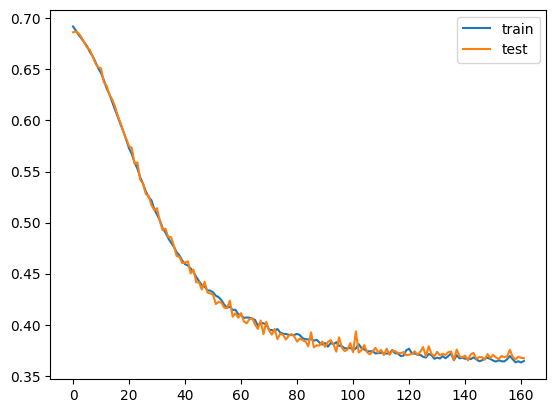

In [21]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()